# CellRank v2 Trajectory Inference on LARRY Day-2 Data

CellRank v2 (Lange et al. 2022) computes directed cell transitions using a kernel-based
framework. Here we use the **PseudotimeKernel** with **DPT (Diffusion Pseudotime)** as
the time coordinate, then extract macrostates and fate probabilities via the GPCCA estimator.
As a single-snapshot method we run on day-2 cells only and evaluate against clonal ground truth.

**Pipeline:**
1. Imports and Configuration
2. Load preprocessed LARRY data (`larry_preprocessed.h5ad` from notebook 01)
3. Subset to day-2 cells (subsample undifferentiated cells for compute)
4. k-NN graph and UMAP
5. Select HSC root cell
6. Compute Diffusion Psuedotime (DPT) (input to PseudotimeKernel)
7. Run CellRank v2 with PseudotimeKernel
8. Visualize on UMAP
9. Evaluate against clonal ground-truth fate labels
10. Save

## 1. Imports and Configuration

In [87]:
%matplotlib inline

import os
import sys
print(f"Python: {sys.executable}")

import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata
import cellrank as cr

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

RESULTS_DIR        = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

PREPROCESSED_H5AD  = "larry_preprocessed.h5ad"
OUTPUT_H5AD        = os.path.join(RESULTS_DIR, "larry_day2_cellrank.h5ad")
time_col           = "Time point"
celltype_col       = "Cell type annotation"
clone_col          = "clone_idx"
fate_prob_key      = "cellrank_fate_probabilities"

N_MACROSTATES      = 11
N_UNDIFF_SUBSAMPLE = 10000   # undifferentiated cells to keep; all committed cells are kept

print(f"CellRank version: {cr.__version__}")
print(f"Scanpy version:   {sc.__version__}")
print(f"Results dir:      {RESULTS_DIR}/")

Python: d:\Desktop\brobramming\snapshot-vs-timeseries-trajectory-inference\.venv\Scripts\python.exe
CellRank version: 2.3.1
Scanpy version:   1.12.1
Results dir:      results/


## 2. Load preprocessed data

In [88]:
adata_full = anndata.read_h5ad(PREPROCESSED_H5AD)
print(adata_full)
print("\nobs columns:", list(adata_full.obs.columns))
print("obsm keys:  ", list(adata_full.obsm.keys()))

AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'connectivities', 'distances'

obs columns: ['Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr

## 3. Subset to day-2 cells

In [89]:
adata_d2 = adata_full[adata_full.obs[time_col] == 2].copy()
print(f"Day-2 cells: {adata_d2.n_obs:,} / {adata_full.n_obs:,}")

if clone_col in adata_d2.obs.columns:
    n_cloned = (adata_d2.obs[clone_col].fillna(-1).astype(int) >= 0).sum()
    print(f"  With clonal lineage info: {n_cloned:,} ({100*n_cloned/adata_d2.n_obs:.1f}%)")

if celltype_col in adata_d2.obs.columns:
    n_ct = adata_d2.obs[celltype_col].notna().sum()
    print(f"  With cell-type annotation: {n_ct:,}")
    if n_ct > 0:
        print(adata_d2.obs[celltype_col].value_counts())

Day-2 cells: 28,249 / 130,887
  With clonal lineage info: 4,638 (16.4%)
  With cell-type annotation: 28,249
Cell type annotation
Undifferentiated    25575
Neutrophil           1068
Monocyte              950
Baso                  187
Lymphoid              144
Erythroid             100
Meg                    97
Ccr7_DC                57
Mast                   40
pDC                    16
Eos                    15
Name: count, dtype: int64


## 3b. Subsample undifferentiated cells

GPCCA's Schur decomposition requires a dense matrix when PETSc/SLEPc are unavailable.
At 28k cells that matrix is ~6.4 GB and causes OOM. We subsample the undifferentiated
mass to `N_UNDIFF_SUBSAMPLE` (5,000) cells while keeping every committed cell intact.
All cells with `fate_frac_*` ground-truth labels are preserved so the
evaluation in section 9 is unaffected.

In [90]:
np.random.seed(42)
committed_mask = adata_d2.obs[celltype_col] != "Undifferentiated"
undiff_idx     = np.where(~committed_mask)[0]
keep_undiff    = np.random.choice(undiff_idx, size=N_UNDIFF_SUBSAMPLE, replace=False)
keep_idx       = np.sort(np.concatenate([np.where(committed_mask)[0], keep_undiff]))
adata_d2       = adata_d2[keep_idx].copy()

print(f"Subsampled: {adata_d2.n_obs:,} cells  (was 28,249)")
print(adata_d2.obs[celltype_col].value_counts())

Subsampled: 12,674 cells  (was 28,249)
Cell type annotation
Undifferentiated    10000
Neutrophil           1068
Monocyte              950
Baso                  187
Lymphoid              144
Erythroid             100
Meg                    97
Ccr7_DC                57
Mast                   40
pDC                    16
Eos                    15
Name: count, dtype: int64


## 4. k-NN graph and UMAP

In [91]:
print("Computing k-NN graph (n_neighbors=30, n_pcs=50)...")
sc.pp.neighbors(adata_d2, n_neighbors=30, n_pcs=50, use_rep="X_pca")

print("Computing UMAP for visualization...")
sc.tl.umap(adata_d2, random_state=42)

umap_d2 = adata_d2.obsm["X_umap"]

Computing k-NN graph (n_neighbors=30, n_pcs=50)...
Computing UMAP for visualization...


## 5. Select start cell

Select the day-2 cell with the highest composite HSC/LMPP marker score
(*Procr*, *Ly6a*, *Flt3*, *Gata2*, *Kit*, *Cd34*). Falls back to the cell nearest
to the PCA centroid if no markers are found.

In [92]:
def get_gene_expr(adata, gene_name, prefer_layer="log1p_norm"):
    """Dense expression array for gene_name; prefers log1p_norm layer over scaled X."""
    hits = adata.var.index[adata.var.index == gene_name].tolist()
    if not hits:
        return None
    idx = adata.var.index.tolist().index(hits[0])
    if prefer_layer in adata.layers:
        col = adata.layers[prefer_layer][:, idx]
    else:
        col = adata.X[:, idx]
    return np.asarray(col.todense()).flatten() if sp.issparse(col) else np.asarray(col).flatten()


# HSC / LMPP markers (mouse); score on log-normalised counts so magnitude is preserved
hsc_markers = ["Procr", "Ly6a", "Flt3", "Gata2", "Kit", "Cd34"]
score = np.zeros(adata_d2.n_obs)
found_markers = []

for gene in hsc_markers:
    expr = get_gene_expr(adata_d2, gene)
    if expr is not None:
        mx = expr.max()
        if mx > 0:
            score += expr / mx
        found_markers.append(gene)

if found_markers:
    start_idx = int(np.argmax(score))
    start_cell = adata_d2.obs_names[start_idx]
    print(f"HSC markers found: {found_markers}")
    print(f"Start cell (max HSC score): {start_cell}  (index {start_idx})")
    ct = adata_d2.obs.loc[start_cell, celltype_col] if celltype_col in adata_d2.obs else "?"
    print(f"Cell type: {ct}")
else:
    pca_d2 = adata_d2.obsm["X_pca"][:, :10]
    centroid = pca_d2.mean(axis=0)
    start_idx = int(np.argmin(np.linalg.norm(pca_d2 - centroid, axis=1)))
    start_cell = adata_d2.obs_names[start_idx]
    print(f"No HSC markers found. Fallback to PCA centroid: {start_cell}")

HSC markers found: ['Procr', 'Ly6a', 'Flt3', 'Gata2', 'Kit', 'Cd34']
Start cell (max HSC score): 59870  (index 11440)
Cell type: Lymphoid


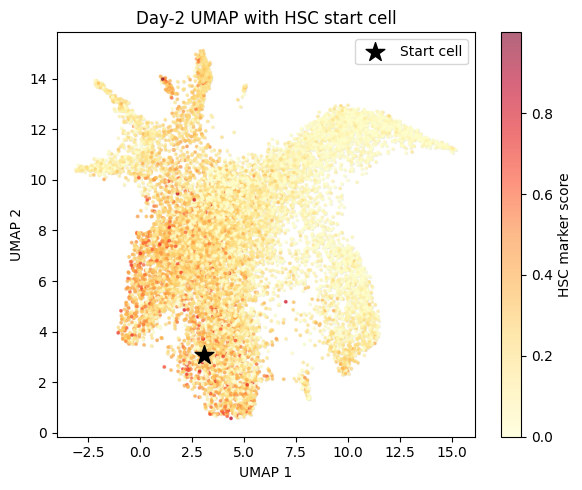

In [93]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=2, alpha=0.3, color="lightgray")

if found_markers:
    score_norm = (score - score.min()) / (score.max() - score.min() + 1e-9)
    sc_ = ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.6,
                     c=score_norm, cmap="YlOrRd")
    plt.colorbar(sc_, ax=ax, label="HSC marker score")

ax.scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1],
           s=200, color="black", marker="*", zorder=5, label="Start cell")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Day-2 UMAP with HSC start cell")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Diffusion Pseudotime

DPT computes pseudotime via random-walk distances on a diffusion
manifold.  We use it as the time coordinate for the PseudotimeKernel rather than Palantir
pseudotime, keeping each method self-contained.

In [94]:
print("Computing diffusion map (n_comps=15)...")
sc.tl.diffmap(adata_d2, n_comps=15)

# Root cell for DPT must be set before calling sc.tl.dpt
adata_d2.uns["iroot"] = start_idx
print(f"iroot: index {start_idx} ({start_cell})")

print("Computing DPT pseudotime (n_dcs=10)...")
sc.tl.dpt(adata_d2, n_dcs=10)

dpt_vals = adata_d2.obs["dpt_pseudotime"].values
print(f"dpt_pseudotime  range : {np.nanmin(dpt_vals):.4f} – {np.nanmax(dpt_vals):.4f}")
print(f"                NaN   : {np.isnan(dpt_vals).sum()} / {len(dpt_vals)}")

Computing diffusion map (n_comps=15)...
iroot: index 11440 (59870)
Computing DPT pseudotime (n_dcs=10)...
dpt_pseudotime  range : 0.0000 – 1.0000
                NaN   : 0 / 12674


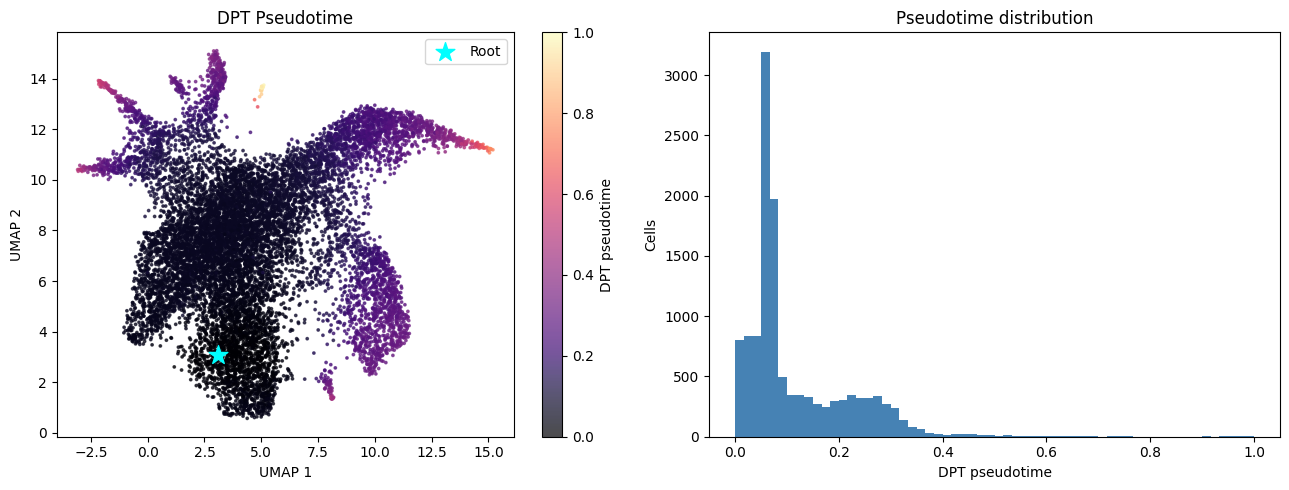

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                      c=dpt_vals, cmap="magma")
plt.colorbar(sc0, ax=axes[0], label="DPT pseudotime")
axes[0].scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1],
                s=200, color="cyan", marker="*", zorder=5, label="Root")
axes[0].set(xlabel="UMAP 1", ylabel="UMAP 2", title="DPT Pseudotime")
axes[0].legend()

axes[1].hist(dpt_vals[~np.isnan(dpt_vals)], bins=60, color="steelblue", edgecolor="none")
axes[1].set(xlabel="DPT pseudotime", ylabel="Cells", title="Pseudotime distribution")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cellrank_dpt.png"), dpi=80, bbox_inches="tight")
plt.show()

## 7. Run CellRank v2

### 7a. Transition matrix

The `PseudotimeKernel` biases the k-NN graph toward cells with higher pseudotime,
creating an asymmetric transition matrix that encodes directed differentiation flow.

In [96]:
print("Building PseudotimeKernel (time_key='dpt_pseudotime')...")
pk = cr.kernels.PseudotimeKernel(adata_d2, time_key="dpt_pseudotime")
pk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
print("Transition matrix computed.")
print(pk)

Building PseudotimeKernel (time_key='dpt_pseudotime')...
INFO     Computing transition matrix based on pseudotime                                                           


100%|██████████| 12674/12674 [00:03<00:00, 3971.99cell/s]


INFO         Finish (4.59s)                                                                                        
Transition matrix computed.
PseudotimeKernel[n=12674]


### 7b. Macrostates

We fit our estimator to `N_MACROSTATES` macro states. 

Aside: This section resulted in OOM due to no available petsc4py installation for Windows; thus, I subsampled the cells (section 3b) to enable the dense Schur decomposition. This should not impact the quality of the experiment, but if we had more time, I would move to a Linux system and perform the rest of the experiment without subsampling.

In [97]:
print(f"Fitting GPCCA estimator (n_states={N_MACROSTATES}, cluster_key='{celltype_col}')...")
estimator = cr.estimators.GPCCA(pk)
estimator.compute_macrostates(n_states=N_MACROSTATES, cluster_key=celltype_col)

print("\nMacrostate cell counts:")
print(estimator.macrostates.value_counts().sort_values(ascending=False))

Fitting GPCCA estimator (n_states=11, cluster_key='Cell type annotation')...
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                                                              
             Finish (697.64s)                                                                                  

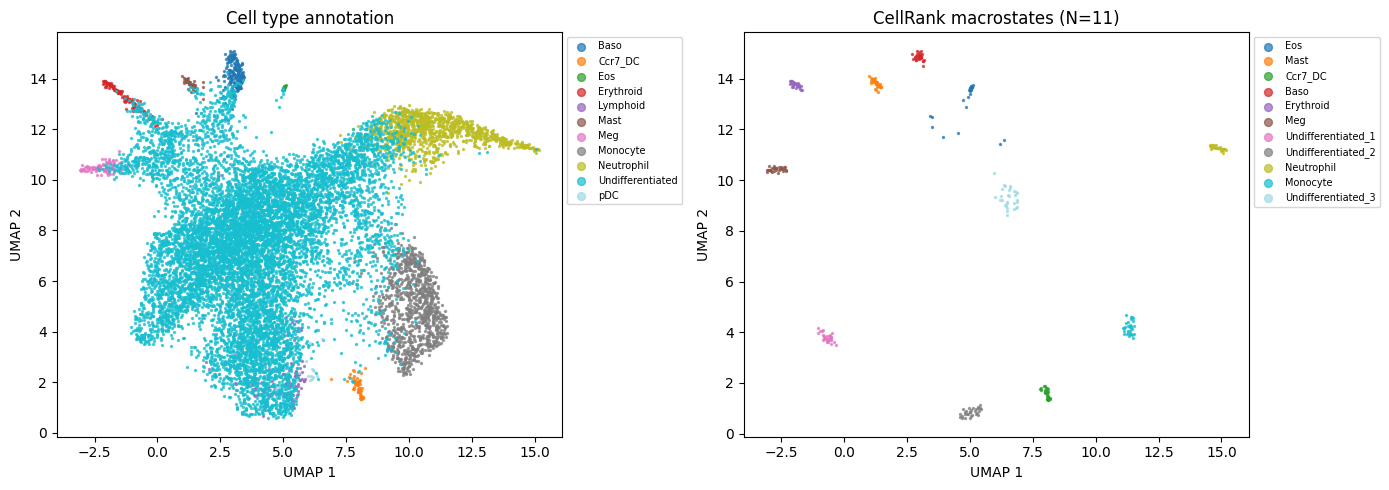

In [98]:
# Color UMAP by macrostate
macrostates_series = estimator.macrostates
cats = macrostates_series.cat.categories.tolist()
cmap_ms = plt.get_cmap("tab20", len(cats))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cts = sorted(adata_d2.obs[celltype_col].dropna().unique())
ct_cmap = plt.get_cmap("tab20", len(cts))
unlab = adata_d2.obs[celltype_col].isna().values
axes[0].scatter(umap_d2[unlab, 0], umap_d2[unlab, 1], s=1, alpha=0.15, color="lightgray")
for i, ct in enumerate(cts):
    m = (adata_d2.obs[celltype_col] == ct).values
    axes[0].scatter(umap_d2[m, 0], umap_d2[m, 1], s=2, alpha=0.7, color=ct_cmap(i), label=ct)
axes[0].set(xlabel="UMAP 1", ylabel="UMAP 2", title="Cell type annotation")
axes[0].legend(markerscale=4, fontsize=7, bbox_to_anchor=(1, 1))

for i, cat in enumerate(cats):
    m = (macrostates_series == cat).values
    axes[1].scatter(umap_d2[m, 0], umap_d2[m, 1], s=2, alpha=0.7, color=cmap_ms(i), label=cat)
axes[1].set(xlabel="UMAP 1", ylabel="UMAP 2", title=f"CellRank macrostates (N={N_MACROSTATES})")
axes[1].legend(markerscale=4, fontsize=7, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cellrank_macrostates.png"), dpi=80, bbox_inches="tight")
plt.show()

### 7c. Terminal state assignment

We select terminal states using our estimator's `predict_terminal_states()`

In [99]:
estimator.predict_terminal_states()

all_terminal = list(estimator.terminal_states.cat.categories)
filtered     = [s for s in all_terminal if "Undifferentiated" not in s]
estimator.set_terminal_states(states=filtered)

print("Terminal states:")
print(estimator.terminal_states.value_counts().sort_values(ascending=False))
print("\nTerminal state names:", list(estimator.terminal_states.cat.categories))

INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                                                                 
                `.terminal_states_probabilities`                                                                   
                `.terminal_states_memberships                                                                      
             Finish`                                                                                               
INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                      

### 7d. Fate probabilities

In [100]:
print("Computing fate probabilities...")
estimator.compute_fate_probabilities()
print("Done.")

fate_prob_arr   = np.array(adata_d2.obsm["lineages_fwd"])
fate_prob_names = list(estimator.terminal_states.cat.categories)

print(f"Fate probability matrix: {fate_prob_arr.shape}")
print(f"Terminal state names:    {fate_prob_names}")

adata_d2.obsm[fate_prob_key]            = fate_prob_arr
adata_d2.uns["cellrank_terminal_names"] = fate_prob_names

Computing fate probabilities...
INFO     Computing fate probabilities                                                                              


100%|██████████| 8/8 [00:04<00:00,  1.65/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (4.99s)                                                                                        
Done.
Fate probability matrix: (12674, 8)
Terminal state names:    [np.str_('Eos'), np.str_('Mast'), np.str_('Ccr7_DC'), np.str_('Baso'), np.str_('Erythroid'), np.str_('Meg'), np.str_('Neutrophil'), np.str_('Monocyte')]


## 8. Visualize CellRank results

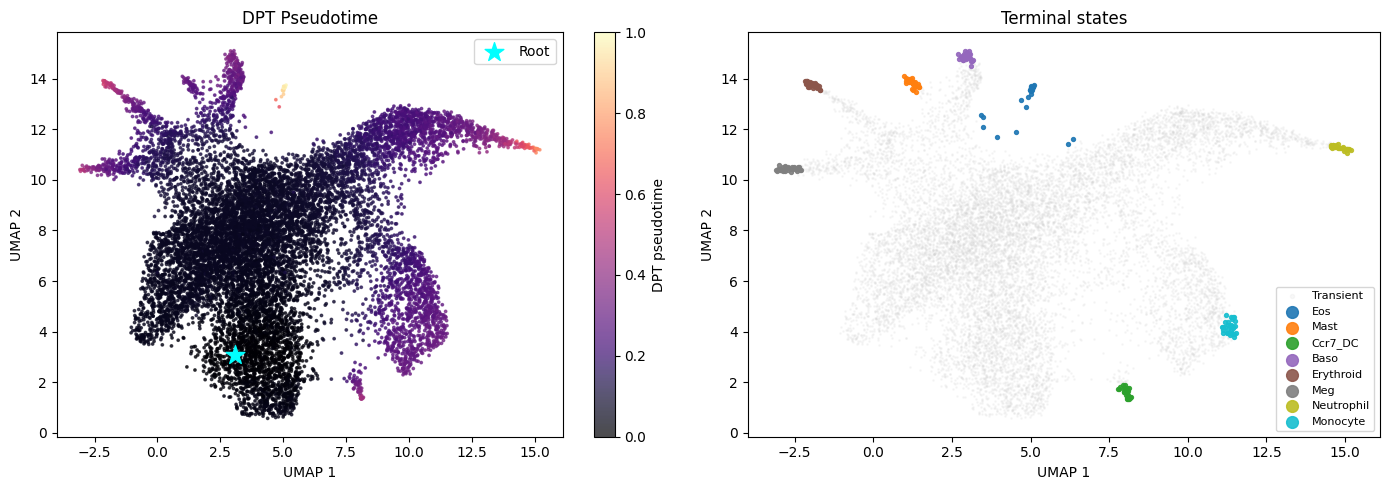

In [101]:
# Pseudotime + terminal state assignments side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                      c=adata_d2.obs["dpt_pseudotime"], cmap="magma")
plt.colorbar(sc0, ax=axes[0], label="DPT pseudotime")
axes[0].scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1],
                s=200, color="cyan", marker="*", zorder=5, label="Root")
axes[0].set(xlabel="UMAP 1", ylabel="UMAP 2", title="DPT Pseudotime")
axes[0].legend()

# Terminal states
ts_series = estimator.terminal_states
ts_cats   = [t for t in ts_series.cat.categories.tolist() if "Undifferentiated" not in t]
ts_cmap   = plt.get_cmap("tab10", len(ts_cats))
non_term  = ts_series.isna().values
axes[1].scatter(umap_d2[non_term, 0], umap_d2[non_term, 1],
                s=1, alpha=0.15, color="lightgray", label="Transient")
for i, ts in enumerate(ts_cats):
    m = (ts_series == ts).values
    axes[1].scatter(umap_d2[m, 0], umap_d2[m, 1], s=8, alpha=0.9,
                    color=ts_cmap(i), label=ts, zorder=3)
axes[1].set(xlabel="UMAP 1", ylabel="UMAP 2", title="Terminal states")
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cellrank_overview.png"), dpi=80, bbox_inches="tight")
plt.show()

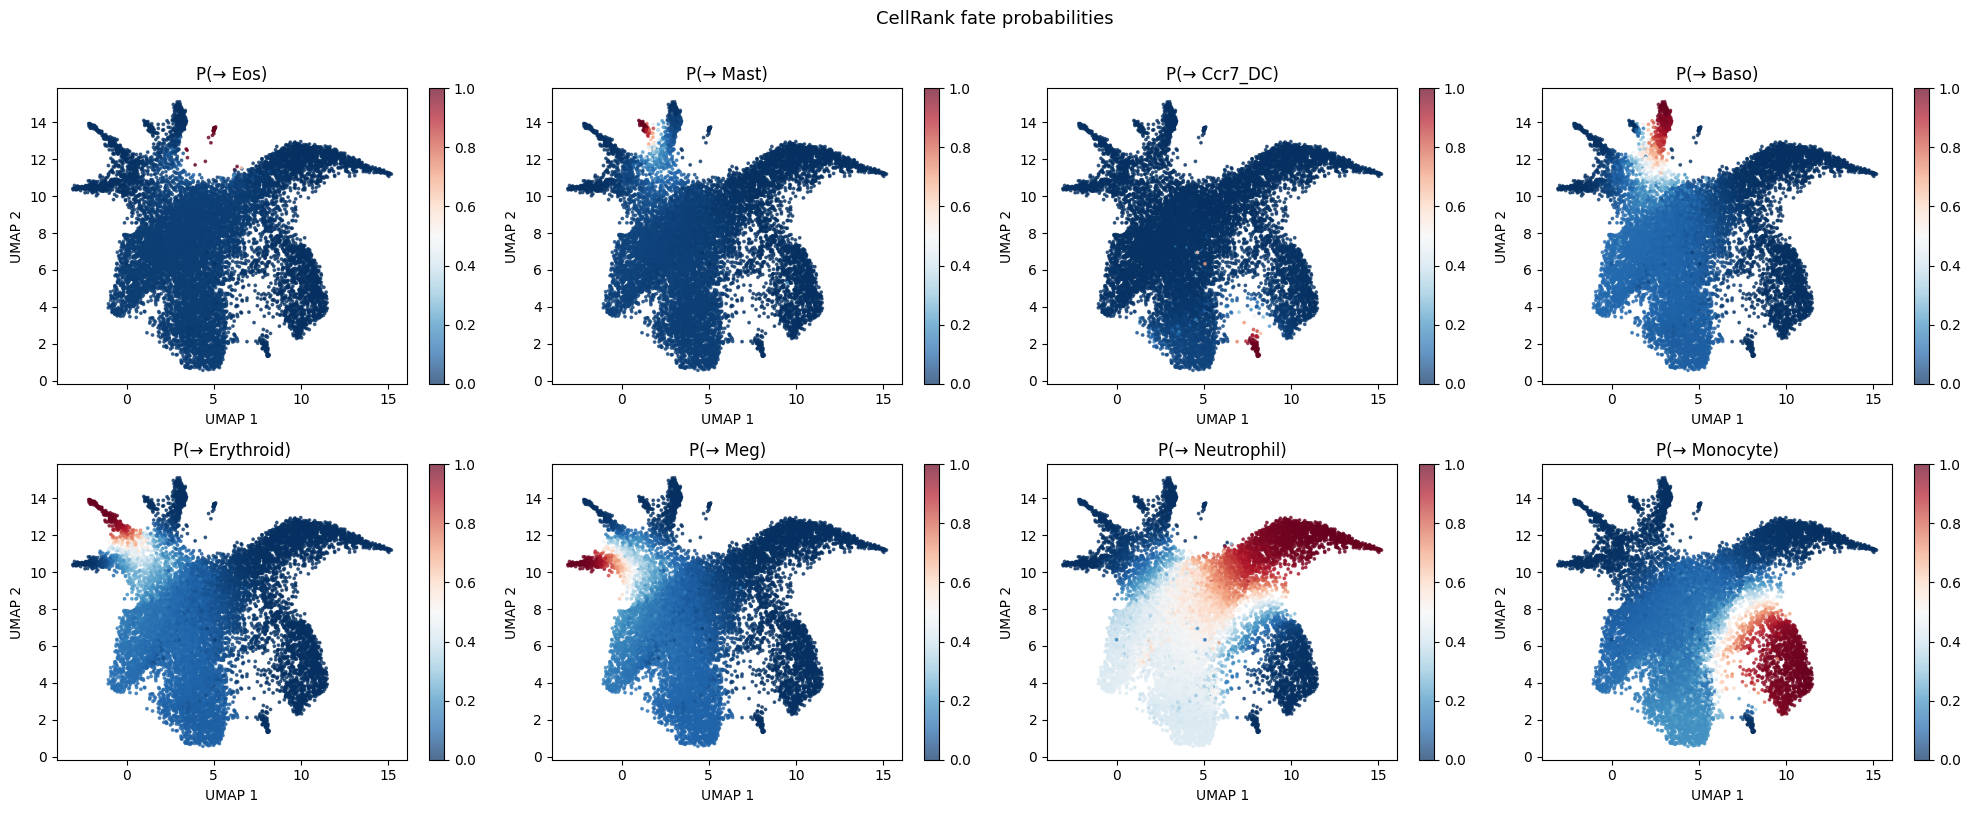

In [102]:
# Per-lineage fate probability UMAP panels
n_branches = len(fate_prob_names)
ncols = min(n_branches, 4)
nrows = (n_branches + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (bname, ax) in enumerate(zip(fate_prob_names, axes)):
    sc_ = ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                     c=fate_prob_arr[:, i], cmap="RdBu_r", vmin=0, vmax=1)
    plt.colorbar(sc_, ax=ax)
    ax.set_title(f"P(→ {bname})")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

for ax in axes[n_branches:]:
    ax.set_visible(False)

plt.suptitle("CellRank fate probabilities", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cellrank_fate_probs.png"), dpi=80, bbox_inches="tight")
plt.show()

## 9. Evaluate against clonal ground-truth fate labels

For day-2 cells with a clone assignment we know the observed fate from `fate_frac_*`
columns (computed in notebook 01 section 7b). We compare CellRank fate probabilities
to observed fate fractions using three metrics:
- **9a** Pearson r heatmap (predicted branch × observed lineage)
- **9b** Neutrophil–Monocyte bias correlation (Weinreb 2020 standard)
- **9c** Cross entropy of predicted vs observed fate distributions

In [103]:
# Collect fate fraction columns from adata_d2
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
print(f"Fate fraction columns found: {len(fate_frac_cols)}")
for c in fate_frac_cols:
    print(f"  {c}")

has_fate = pd.Series(False, index=adata_d2.obs_names)
if fate_frac_cols:
    has_fate = adata_d2.obs[fate_frac_cols[0]].notna()
    n = has_fate.sum()
    print(f"\nDay-2 cells with ground-truth fate fractions: {n:,} / {adata_d2.n_obs:,}")
    print("\nMean fate fractions across cloned day-2 cells:")
    means = adata_d2.obs.loc[has_fate, fate_frac_cols].mean().sort_values(ascending=False)
    print(means.rename(lambda c: c.replace("fate_frac_", "")).round(3).to_string())
else:
    print("No fate_frac_* columns found. Re-run notebook 01 section 7b.")

Fate fraction columns found: 11
  fate_frac_Baso
  fate_frac_Ccr7_DC
  fate_frac_Eos
  fate_frac_Erythroid
  fate_frac_Lymphoid
  fate_frac_Mast
  fate_frac_Meg
  fate_frac_Monocyte
  fate_frac_Neutrophil
  fate_frac_Undifferentiated
  fate_frac_pDC

Day-2 cells with ground-truth fate fractions: 1,107 / 12,674

Mean fate fractions across cloned day-2 cells:
Undifferentiated    0.391
Neutrophil          0.239
Monocyte            0.192
Baso                0.085
Meg                 0.032
Lymphoid            0.027
Mast                0.020
Erythroid           0.006
Ccr7_DC             0.005
Eos                 0.003
pDC                 0.001


In [104]:
fate_df_norm = None

if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]
    print(f"Ground-truth fate matrix: {fate_df_norm.shape[0]:,} cells × {fate_df_norm.shape[1]} lineages")
    print(f"Lineages: {list(fate_df_norm.columns)}")
    print(fate_df_norm.head(3).round(3))
else:
    print("Skipping: no fate fractions available.")

Ground-truth fate matrix: 1,107 cells × 11 lineages
Lineages: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']
       Baso  Ccr7_DC  Eos  Erythroid  Lymphoid  Mast  Meg  Monocyte  \
13210   0.0      0.0  0.0        0.0       0.0   0.0  0.0       0.0   
13226   0.0      0.0  0.0        0.0       0.0   0.0  1.0       0.0   
13259   0.0      0.0  0.0        0.0       0.0   0.0  0.0       0.0   

       Neutrophil  Undifferentiated  pDC  
13210         1.0               0.0  0.0  
13226         0.0               0.0  0.0  
13259         1.0               0.0  0.0  


### 9a. Pearson r heatmap

For each (observed lineage, predicted branch) pair, compute Pearson r over all cloned
day-2 cells. A well-calibrated method should show high r on the diagonal.

Cells with both CellRank probs and fate labels: 1,107
Terminal states used: ['Eos', 'Mast', 'Ccr7_DC', 'Baso', 'Erythroid', 'Meg', 'Neutrophil', 'Monocyte']

Pearson r (observed fate fraction × CellRank fate probability):
                    Eos   Mast  Ccr7_DC   Baso  Erythroid    Meg  Neutrophil  Monocyte
Baso              0.187  0.123   -0.054  0.643      0.058 -0.057      -0.352    -0.123
Ccr7_DC          -0.074 -0.021    0.015 -0.035     -0.024 -0.037      -0.079     0.210
Eos               0.100  0.010   -0.004  0.039     -0.002 -0.008      -0.015    -0.017
Erythroid        -0.090  0.024   -0.017 -0.004      0.278  0.057      -0.128    -0.059
Lymphoid          0.031 -0.023    0.079 -0.023     -0.017 -0.007      -0.001     0.036
Mast             -0.181  0.722   -0.034  0.081      0.026 -0.028      -0.243    -0.115
Meg              -0.233 -0.013   -0.039 -0.027      0.360  0.465      -0.292    -0.115
Monocyte         -0.071 -0.115    0.019 -0.164     -0.189 -0.178       0.048     0

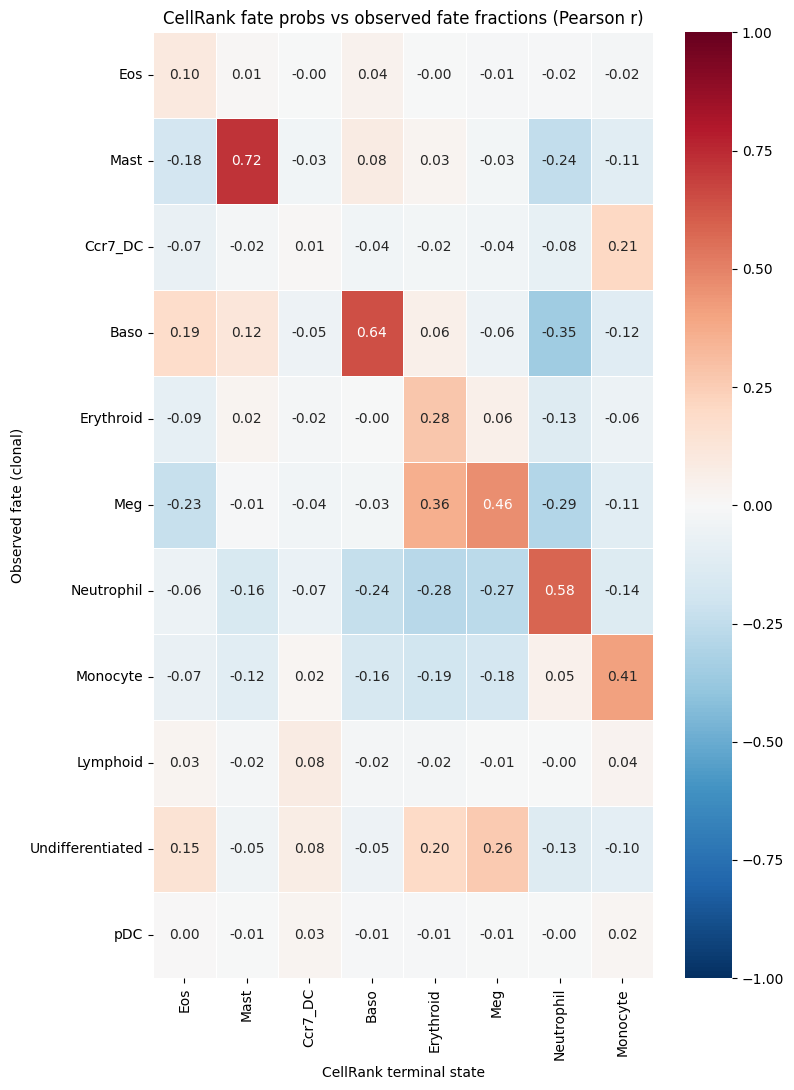

In [105]:
corr_df = None

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    fp_names = [str(n) for n in adata_d2.uns["cellrank_terminal_names"]]
    fp_arr   = adata_d2.obsm[fate_prob_key]
    n_cols   = min(fp_arr.shape[1], len(fp_names))
    bp_df    = pd.DataFrame(fp_arr[:, :n_cols], index=adata_d2.obs_names, columns=fp_names[:n_cols])
    bp_df    = bp_df[[c for c in bp_df.columns if "Undifferentiated" not in c]]

    common   = fate_df_norm.index.intersection(bp_df.index)
    fate_sub = fate_df_norm.loc[common]
    bp_sub   = bp_df.loc[common]
    print(f"Cells with both CellRank probs and fate labels: {len(common):,}")
    print(f"Terminal states used: {list(bp_df.columns)}")

    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)

    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)
    print("\nPearson r (observed fate fraction × CellRank fate probability):")
    print(corr_df.round(3).to_string())

    identified   = [c for c in corr_df.columns if c in corr_df.index]
    unidentified = [r for r in corr_df.index if r not in corr_df.columns]
    corr_df_plot = corr_df.loc[identified + unidentified]

    fig, ax = plt.subplots(figsize=(max(6, len(bp_sub.columns)), max(4, len(corr_df_plot))))
    sns.heatmap(corr_df_plot, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title("CellRank fate probs vs observed fate fractions (Pearson r)")
    ax.set_xlabel("CellRank terminal state")
    ax.set_ylabel("Observed fate (clonal)")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "cellrank_corr_heatmap.png"), dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: no fate fractions or fate probabilities available.")

### 9b. Neutrophil–Monocyte bias correlation

Weinreb 2020 benchmark: among cells with both Neu and Mono clone descendants,
does the model's predicted Neutrophil probability rank-correlate with the observed
Neu / (Neu + Mono) ratio?  Diagonal r ≈ 0.3–0.4 is reported for working methods.

Neu–Mono bias  Pearson r: 0.3472  (p=1.98e-19)
(CellRank branch 'Neutrophil' used as Neutrophil predictor)


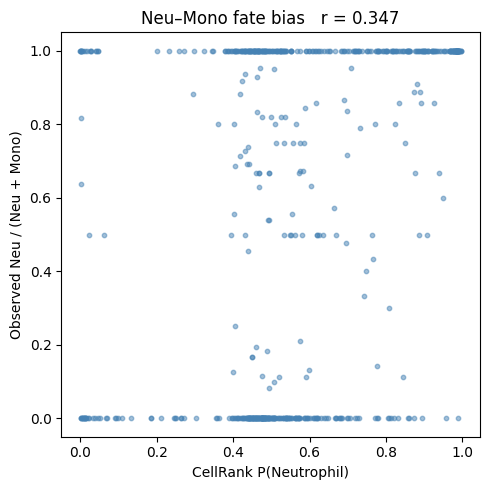

In [106]:
NEU_KEYS  = ["Neutrophil", "Neu"]
MONO_KEYS = ["Monocyte",   "Mono"]

if fate_df_norm is not None and corr_df is not None:
    neu_col  = next((c for c in fate_df_norm.columns if c in NEU_KEYS),  None)
    mono_col = next((c for c in fate_df_norm.columns if c in MONO_KEYS), None)

    if neu_col and mono_col:
        common   = fate_df_norm.index.intersection(bp_df.index)
        fate_sub = fate_df_norm.loc[common]
        bp_sub   = bp_df.loc[common]

        denom    = fate_sub[neu_col] + fate_sub[mono_col]
        obs_bias = (fate_sub[neu_col] / denom.replace(0, np.nan)).dropna()

        # Use the CellRank column with highest |r| for Neutrophil
        best_branch = corr_df.loc[neu_col].abs().idxmax()
        pred_bias   = bp_sub.loc[obs_bias.index, best_branch].values
        r, p        = stats.pearsonr(pred_bias, obs_bias.values)

        print(f"Neu–Mono bias  Pearson r: {r:.4f}  (p={p:.2e})")
        print(f"(CellRank branch '{best_branch}' used as Neutrophil predictor)")

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(pred_bias, obs_bias.values, s=10, alpha=0.5, color="steelblue")
        ax.set_xlabel(f"CellRank P({best_branch})")
        ax.set_ylabel("Observed Neu / (Neu + Mono)")
        ax.set_title(f"Neu–Mono fate bias   r = {r:.3f}")
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, "cellrank_neu_mono_bias.png"), dpi=80, bbox_inches="tight")
        plt.show()
    else:
        print(f"Neu/Mono not in fate_df_norm. Available: {list(fate_df_norm.columns)}")
else:
    print("Skipping: correlation matrix not available.")

### 9c. Cross entropy of predicted vs observed fate distributions

For each cloned day-2 cell, treat the observed fate fractions as a distribution `p`
and the model's predicted fate probabilities as `q`, then compute the cross entropy
`H(p, q) = −∑ p_k log(q_k + ε)`.  Lower is better; the theoretical minimum is the
entropy `H(p)` (achieved when predictions are perfect).  Only lineages present in both
the observed fractions and the CellRank terminal states are included.

Shared lineages (CellRank ∩ observed): ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil']
  (8 of 11 observed lineages covered)

Cross entropy (8 shared lineages, 820 cells):
  H(p, q)  mean:   1.3019
  H(p, q)  median: 1.0168
  H(p)     mean:   0.1051  (lower bound — perfect predictions)
  Excess   mean:   1.1968  (H(p,q) − H(p))


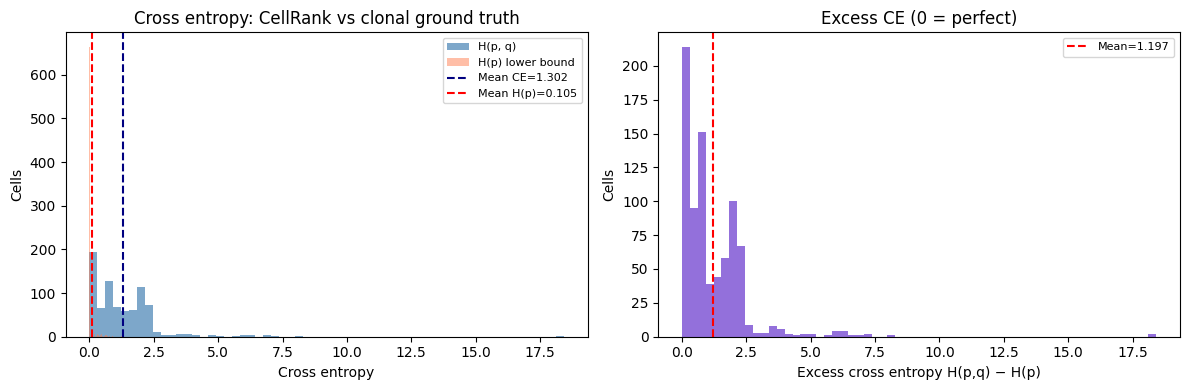

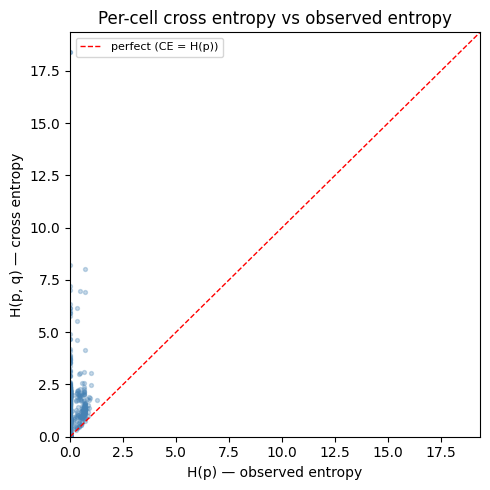

In [107]:
EPS = 1e-8

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    fp_names  = [str(n) for n in adata_d2.uns["cellrank_terminal_names"]]
    fp_arr    = adata_d2.obsm[fate_prob_key]
    n_cols    = min(fp_arr.shape[1], len(fp_names))
    bp_df_ce  = pd.DataFrame(fp_arr[:, :n_cols], index=adata_d2.obs_names, columns=fp_names[:n_cols])
    bp_df_ce  = bp_df_ce[[c for c in bp_df_ce.columns if "Undifferentiated" not in c]]

    shared_ce = sorted(set(fate_df_norm.columns) & set(bp_df_ce.columns))
    print(f"Shared lineages (CellRank ∩ observed): {shared_ce}")
    print(f"  ({len(shared_ce)} of {len(fate_df_norm.columns)} observed lineages covered)")

    common_ce   = fate_df_norm.index.intersection(bp_df_ce.index)
    fate_sub_ce = fate_df_norm.loc[common_ce, shared_ce].values.astype(float)
    bp_sub_ce   = bp_df_ce.loc[common_ce, shared_ce].values.astype(float)

    per_cell_ce    = []
    per_cell_h_obs = []

    for obs_vec, pred_vec in zip(fate_sub_ce, bp_sub_ce):
        obs_s  = obs_vec.sum()
        pred_s = pred_vec.sum()
        if obs_s > 0 and pred_s > 0:
            p = obs_vec  / obs_s
            q = pred_vec / pred_s
            per_cell_ce.append(-np.sum(p * np.log(q + EPS)))
            per_cell_h_obs.append(-np.sum(p[p > 0] * np.log(p[p > 0])))

    per_cell_ce    = np.array(per_cell_ce)
    per_cell_h_obs = np.array(per_cell_h_obs)
    excess_ce      = per_cell_ce - per_cell_h_obs

    print(f"\nCross entropy ({len(shared_ce)} shared lineages, {len(per_cell_ce):,} cells):")
    print(f"  H(p, q)  mean:   {per_cell_ce.mean():.4f}")
    print(f"  H(p, q)  median: {np.median(per_cell_ce):.4f}")
    print(f"  H(p)     mean:   {per_cell_h_obs.mean():.4f}  (lower bound — perfect predictions)")
    print(f"  Excess   mean:   {excess_ce.mean():.4f}  (H(p,q) − H(p))")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(per_cell_ce,    bins=60, color="steelblue", edgecolor="none", alpha=0.7, label="H(p, q)")
    axes[0].hist(per_cell_h_obs, bins=60, color="coral",     edgecolor="none", alpha=0.5, label="H(p) lower bound")
    axes[0].axvline(per_cell_ce.mean(),    color="navy", ls="--", lw=1.5, label=f"Mean CE={per_cell_ce.mean():.3f}")
    axes[0].axvline(per_cell_h_obs.mean(), color="red",  ls="--", lw=1.5, label=f"Mean H(p)={per_cell_h_obs.mean():.3f}")
    axes[0].set(xlabel="Cross entropy", ylabel="Cells", title="Cross entropy: CellRank vs clonal ground truth")
    axes[0].legend(fontsize=8)

    axes[1].hist(excess_ce, bins=60, color="mediumpurple", edgecolor="none")
    axes[1].axvline(excess_ce.mean(), color="red", ls="--", lw=1.5, label=f"Mean={excess_ce.mean():.3f}")
    axes[1].set(xlabel="Excess cross entropy H(p,q) − H(p)", ylabel="Cells", title="Excess CE (0 = perfect)")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "cellrank_cross_entropy.png"), dpi=80, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(per_cell_h_obs, per_cell_ce, s=8, alpha=0.3, color="steelblue")
    lim = max(per_cell_ce.max(), per_cell_h_obs.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1, label="perfect (CE = H(p))")
    ax.set(xlabel="H(p) — observed entropy", ylabel="H(p, q) — cross entropy",
           title="Per-cell cross entropy vs observed entropy", xlim=(0, lim), ylim=(0, lim))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "cellrank_cross_entropy_scatter.png"), dpi=80, bbox_inches="tight")
    plt.show()
else:
    print("Skipping: fate fractions or fate probabilities not available.")

## 10. Save

In [108]:
print(f"Saving to {OUTPUT_H5AD} ...")
adata_d2.write_h5ad(OUTPUT_H5AD)

result_cols = [c for c in adata_d2.obs.columns
               if c in [time_col, clone_col, celltype_col, "dpt_pseudotime"]
               or c.startswith("fate_")]
csv_path = os.path.join(RESULTS_DIR, "cellrank_day2_results.csv")
adata_d2.obs[result_cols].to_csv(csv_path)
print(f"CSV saved to {csv_path}")

Saving to results\larry_day2_cellrank.h5ad ...
CSV saved to results\cellrank_day2_results.csv


In [109]:
print("=" * 55)
print("CELLRANK ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Day-2 cells:      {adata_d2.n_obs:,}")
print(f"  Root cell:        {start_cell}")
dpt = adata_d2.obs["dpt_pseudotime"]
print(f"  DPT pseudotime:   {dpt.min():.3f} – {dpt.max():.3f}")
print(f"  N macrostates:    {N_MACROSTATES}")
if fate_prob_key in adata_d2.obsm:
    print(f"  Terminal states:  {adata_d2.uns['cellrank_terminal_names']}")
    print(f"  # terminal:       {adata_d2.obsm[fate_prob_key].shape[1]}")
print(f"  Output h5ad:      {OUTPUT_H5AD}")

CELLRANK ANALYSIS COMPLETE
  Day-2 cells:      12,674
  Root cell:        59870
  DPT pseudotime:   0.000 – 1.000
  N macrostates:    11
  Terminal states:  [np.str_('Eos'), np.str_('Mast'), np.str_('Ccr7_DC'), np.str_('Baso'), np.str_('Erythroid'), np.str_('Meg'), np.str_('Neutrophil'), np.str_('Monocyte')]
  # terminal:       8
  Output h5ad:      results\larry_day2_cellrank.h5ad


---
## Eval-only checkpoint

Run on a **fresh kernel** to restore all variables needed by the section 8 eval cells
without re-running the full CellRank pipeline. Requires `larry_day2_cellrank.h5ad`.

In [110]:
%matplotlib inline

import os
import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

warnings.filterwarnings("ignore")

RESULTS_DIR   = "results"
OUTPUT_H5AD   = os.path.join(RESULTS_DIR, "larry_day2_cellrank.h5ad")
time_col      = "Time point"
celltype_col  = "Cell type annotation"
clone_col     = "clone_idx"
fate_prob_key = "cellrank_fate_probabilities"

print(f"Loading {OUTPUT_H5AD} ...")
adata_d2 = anndata.read_h5ad(OUTPUT_H5AD)
print(adata_d2)

umap_d2 = adata_d2.obsm["X_umap"]

fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
has_fate = (
    adata_d2.obs[fate_frac_cols[0]].notna()
    if fate_frac_cols
    else pd.Series(False, index=adata_d2.obs_names)
)

fate_df_norm = None
if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]

fp_names = [str(n) for n in adata_d2.uns.get("cellrank_terminal_names", [])]
fp_arr   = adata_d2.obsm.get(fate_prob_key)
bp_df    = None
if fp_arr is not None and fp_names:
    n_cols = min(fp_arr.shape[1], len(fp_names))
    bp_df  = pd.DataFrame(fp_arr[:, :n_cols], index=adata_d2.obs_names, columns=fp_names[:n_cols])
    bp_df  = bp_df[[c for c in bp_df.columns if "Undifferentiated" not in c]]

corr_df = fate_sub = bp_sub = None
if fate_df_norm is not None and bp_df is not None:
    common   = fate_df_norm.index.intersection(bp_df.index)
    fate_sub = fate_df_norm.loc[common]
    bp_sub   = bp_df.loc[common]
    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc].values, bp_sub[bc].values)
    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)

print("\nAll eval-metric variables restored:")
print(f"  adata_d2     {adata_d2.n_obs:,} cells")
print(f"  fate_df_norm {fate_df_norm.shape if fate_df_norm is not None else None}")
print(f"  bp_df        {bp_df.shape if bp_df is not None else None}")
print(f"  fate_sub     {fate_sub.shape if fate_sub is not None else None}")
print(f"  bp_sub       {bp_sub.shape if bp_sub is not None else None}")
print(f"  corr_df      {corr_df.shape if corr_df is not None else None}")
print(f"  columns      {list(bp_df.columns) if bp_df is not None else None}")
print("\nReady — run any eval cell in section 9.")

Loading results\larry_day2_cellrank.h5ad ...
AnnData object with n_obs × n_vars = 12674 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC', 'dpt_pseudotime', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cellrank_terminal_names', 'coarse_fwd', 'diffmap_evals', 'eigendecomposition_fwd', 'hvg', 'iroot', 'log1p', 'macrostates_fwd_colors', 'neighbors', 'pca', 'schur_matrix_fwd', 'term_states_fwd_colors', 'umap'
    obsm: 'X_clone', 'X_diffmap', 'X_pca', 'X_umap', 'cellrank_fate_probabilities', 'lin